# Лабораторная работа 1
# Власов Илья // Мушников Артём


# Задание 1 -- Экспоненциальное распределение



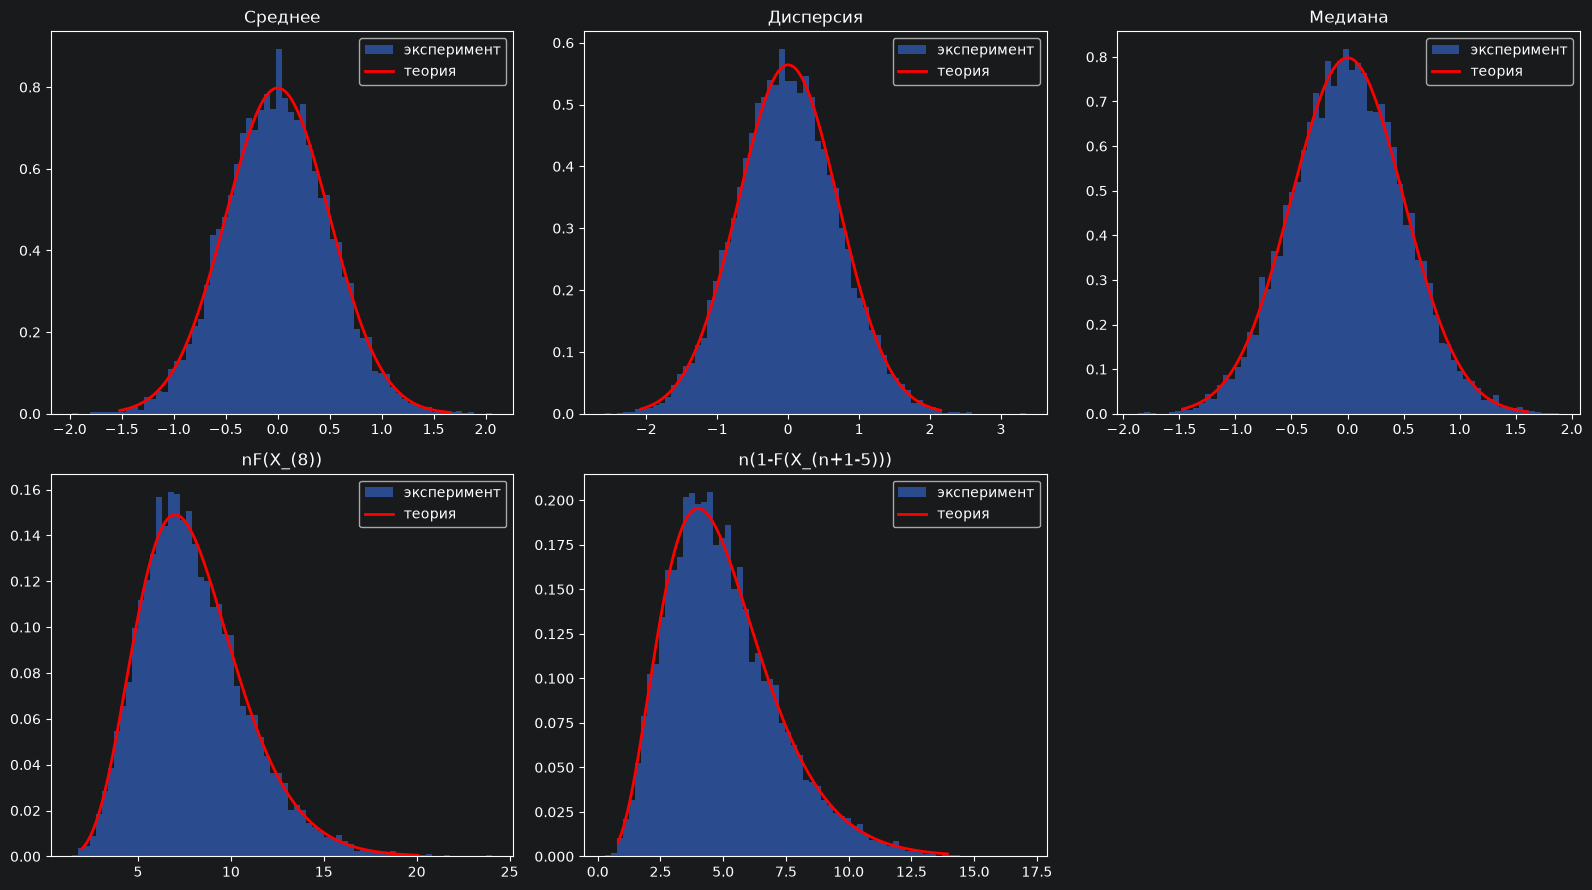

Среднее
  среднее:    -0.0010   теория   0.0000
  дисперсия:   0.2455   теория   0.2500
  медиана:    -0.0011   теория   0.0000
Дисперсия
  среднее:    -0.0051   теория   0.0000
  дисперсия:   0.4986   теория   0.5000
  медиана:    -0.0151   теория   0.0000
Медиана
  среднее:     0.0017   теория   0.0000
  дисперсия:   0.2485   теория   0.2500
  медиана:    -0.0031   теория   0.0000
nF(X_(8))
  среднее:     7.9932   теория   8.0000
  дисперсия:   7.9960   теория   8.0000
  медиана:     7.6178   теория   7.6692
n(1-F(X_(n+1-5)))
  среднее:     5.0030   теория   5.0000
  дисперсия:   4.8248   теория   5.0000
  медиана:     4.6760   теория   4.6709


In [2]:
import math
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt



k = (3 + 14) // 2 # == 8
j = (1 + 10) // 2 # == 5

dist  = stats.expon(scale=1/2)
rng = np.random.default_rng(42)
M = 10_000
N = 10_000

U = rng.random((M, N))

X = dist.ppf(U)

mean = dist.mean()
variance = dist.var()
median = dist.median()
m4 = dist.expect(lambda x: (x - mean) ** 4)   # центральный 4-й момент

sample_means = X.mean(axis=1)
sample_vars = X.var(axis=1)
sample_medians = np.median(X, axis=1)

Xs = np.sort(X, axis=1)
X_k = Xs[:, k - 1]
X_j = Xs[:, N - j]


# нормируем по цпт
RES = {
    "Среднее":   np.sqrt(N) * (sample_means - mean),
    "Дисперсия": np.sqrt(N) * (sample_vars - variance),
    "Медиана":   np.sqrt(N) * (sample_medians - median),
    f"nF(X_({k}))": N * dist.cdf(X_k),
    f"n(1-F(X_(n+1-{j})))": N * dist.sf(X_j),
}

limits = {
    "Среднее":   stats.norm(0, np.sqrt(variance)),
    "Дисперсия": stats.norm(0, np.sqrt(m4 - variance ** 2)),
    "Медиана":   stats.norm(0, 1 / (2 * dist.pdf(median))),
    f"nF(X_({k}))": stats.gamma(k),
    f"n(1-F(X_(n+1-{j})))": stats.gamma(j),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, (name, data) in zip(axes, RES.items()):
    lim = limits[name]
    ax.hist(data, bins=70, density=True, alpha=0.6, label="эксперимент")
    xs = np.linspace(*np.percentile(data, [0.1, 99.9]), 400)
    ax.plot(xs, lim.pdf(xs), "r", lw=2, label="теория")
    ax.set_title(name)
    ax.legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()

for name, data in RES.items():
    lim = limits[name]
    print(f"{name}")
    print(f"  среднее:   {data.mean():8.4f}   теория {lim.mean():8.4f}")
    print(f"  дисперсия: {data.var():8.4f}   теория {lim.var():8.4f}")
    print(f"  медиана:   {np.median(data):8.4f}   теория {lim.median():8.4f}")

# Задание 2

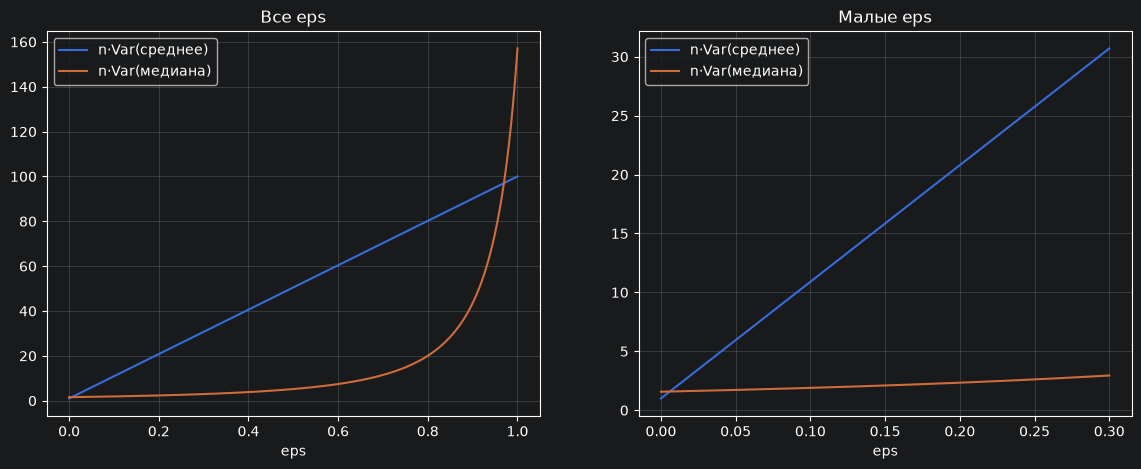

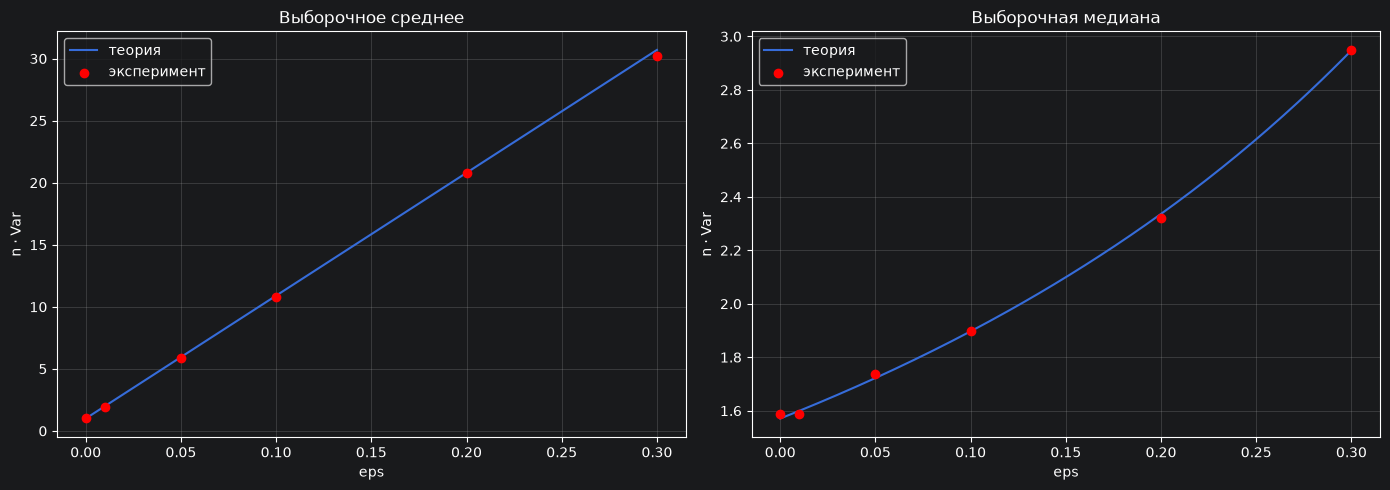

In [3]:
def gen_mix(eps, mu, sigma, tau, size, rng):
    vibros = rng.random(size) < eps
    Z = rng.standard_normal(size)
    return mu + np.where(vibros, tau, sigma) * Z


mu, sigma, tau = 0, 1, 10
eps_grid = np.linspace(0, 1, 501)

def n_var_mean(eps):
    return (1 - eps) * sigma**2 + eps * tau**2

def n_var_median(eps):
    return np.pi / (2 * ((1 - eps) / sigma + eps / tau) ** 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, right in zip(axes, [1.0, 0.3]):
    e = eps_grid[eps_grid <= right]
    ax.plot(e, n_var_mean(e), label="n·Var(среднее)")
    ax.plot(e, n_var_median(e), label="n·Var(медиана)")
    ax.set_xlabel("eps")
    ax.legend()
    ax.grid(alpha=0.3)

axes[0].set_title("Все eps")
axes[1].set_title("Малые eps")
plt.show()

rng = np.random.default_rng(42)
M, n = 10_000, 1_000
eps_list = [0, 0.01, 0.05, 0.1, 0.2, 0.3]

emp_mean, emp_med = [], []
for eps in eps_list:
    X = gen_mix(eps, mu, sigma, tau, (M, n), rng)
    means = X.mean(axis=1)
    meds = np.median(X, axis=1)
    emp_mean.append(n * means.var())
    emp_med.append(n * meds.var())

e = eps_grid[eps_grid <= 0.3]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(e, n_var_mean(e), label="теория")
axes[0].scatter(eps_list, emp_mean, color="red", zorder=3, label="эксперимент")
axes[0].set_title("Выборочное среднее")


axes[1].plot(e, n_var_median(e), label="теория")
axes[1].scatter(eps_list, emp_med, color="red", zorder=3, label="эксперимент")
axes[1].set_title("Выборочная медиана")

for ax in axes:
    ax.set_xlabel("eps")
    ax.set_ylabel("n · Var")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Задание 3

Использование AI в неделю (в часах) по специальностям:

Выборочное среднее:
Все специальности 8.4277522
Humanities:  6.770144086451872
Medical:  7.54672791846819
Business:  8.275898069867601
STEM:  10.488608805365562
Arts:  7.271702342828248

Дисперсия:
Все специальности 68.38446030660128
Humanities:  43.386636604874965
Medical:  54.91958702155867
Business:  64.17731252594187
STEM:  94.73636661936992
Arts:  49.5943688142848

Стандартное отклонение:
Все специальности 8.269489724680797
Humanities:  6.586853315876631
Medical:  7.410775062134775
Business:  8.011074367770023
STEM:  9.733260842049283
Arts:  7.042326945994825

Медиана:
Все специальности 5.8
Humanities:  4.72
Medical:  5.24
Business:  5.82
STEM:  7.4
Arts:  5.07

Минимум:
Все специальности 0.0
Humanities:  0.0
Medical:  0.0
Business:  0.0
STEM:  0.0
Arts:  0.0

Максимум:
Все специальности 40.0
Humanities:  34.0
Medical:  38.0
Business:  40.0
STEM:  40.0
Arts:  36.0

Нижний квартиль:
Все специальности 2.39
Humanities:  1.93
Med

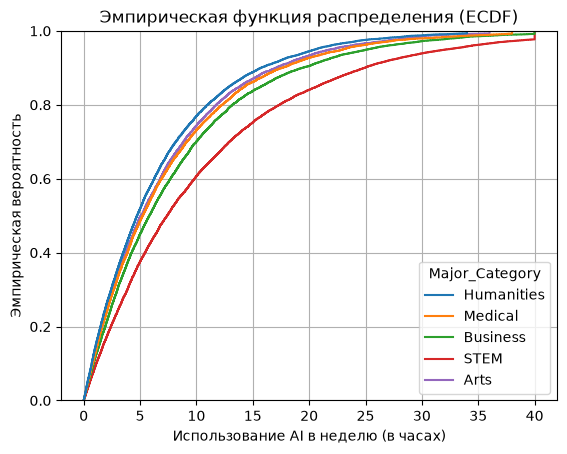

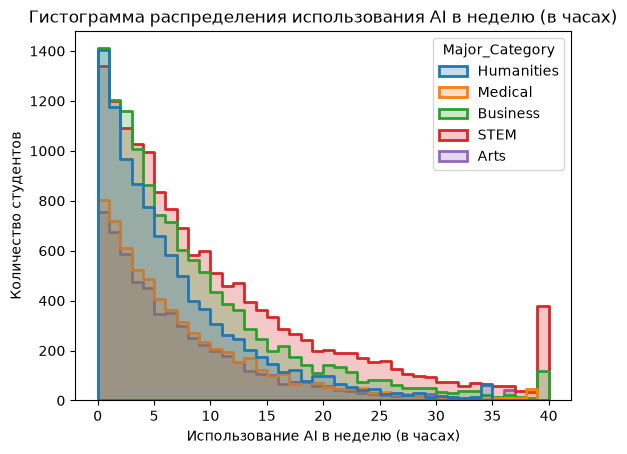

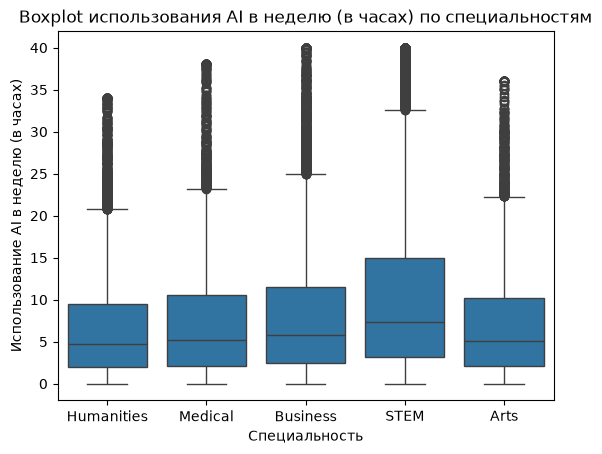

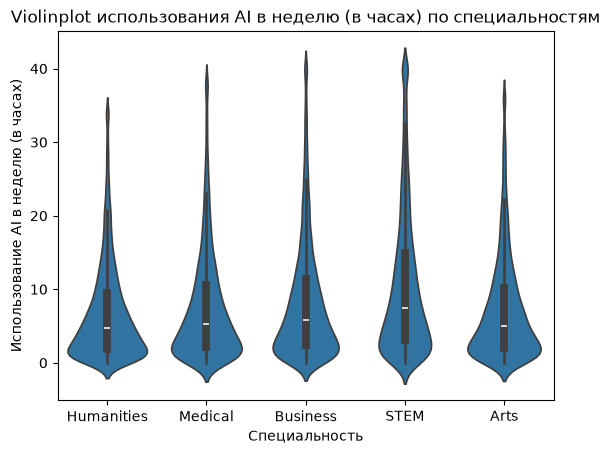

In [23]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def download_dataset(dataset_name):
    path = kagglehub.dataset_download(dataset_name)
    return path

def Characteristics(dataset, type, func):
    print(f"\n{type}:")
    print("Все специальности", func(dataset["Weekly_GenAI_Hours"]))
    for cls in dataset["Major_Category"].unique():
        print(f"{cls}: ", func(dataset[dataset["Major_Category"] == cls]["Weekly_GenAI_Hours"]))

path = download_dataset("laveshjadon/ai-impact-on-students")
dataset = pd.read_csv(path + "/ai_student_impact_dataset (1).csv")

print("Использование AI в неделю (в часах) по специальностям:")

Characteristics(dataset, "Выборочное среднее", lambda x: x.mean())
Characteristics(dataset, "Дисперсия", lambda x: x.var())
Characteristics(dataset, "Стандартное отклонение", lambda x: x.std())
Characteristics(dataset, "Медиана", lambda x: x.median())
Characteristics(dataset, "Минимум", lambda x: x.min())
Characteristics(dataset, "Максимум", lambda x: x.max())
Characteristics(dataset, "Нижний квартиль", lambda x: x.quantile(0.25))
Characteristics(dataset, "Верхний квартиль", lambda x: x.quantile(0.75))
Characteristics(dataset, "Межквартильный размах", lambda x: x.quantile(0.75) - x.quantile(0.25))

sns.ecdfplot(data=dataset, x="Weekly_GenAI_Hours", hue="Major_Category")
plt.title("Эмпирическая функция распределения (ECDF)")
plt.xlabel("Использование AI в неделю (в часах)")
plt.ylabel("Эмпирическая вероятность")
plt.grid(True)
plt.show()

# Видим пик на гистограмме около 40, скорее всего датасет классифицирует всех студентов, которые используют AI более 40 часов в неделю, как "40.0".
sns.histplot(data=dataset, x="Weekly_GenAI_Hours", hue="Major_Category", bins=40, element="step", linewidth=2)
plt.title("Гистограмма распределения использования AI в неделю (в часах)")
plt.xlabel("Использование AI в неделю (в часах)")
plt.ylabel("Количество студентов")
plt.show()

sns.boxplot(data=dataset, x="Major_Category", y="Weekly_GenAI_Hours")
plt.title("Boxplot использования AI в неделю (в часах) по специальностям")
plt.xlabel("Специальность")
plt.ylabel("Использование AI в неделю (в часах)")
plt.show()

sns.violinplot(data=dataset, x="Major_Category", y="Weekly_GenAI_Hours")
plt.title("Violinplot использования AI в неделю (в часах) по специальностям")
plt.xlabel("Специальность")
plt.ylabel("Использование AI в неделю (в часах)")
plt.show()
